# Assignment 2: Project Text Classification Models
**Course**: Big Data Analytics (BDA) — 6th Semester  
**Domain**: HDA-4 | **Group**: 4  

**Team Members**:  
- Krishna Sikheriya (IIT2023139)  
- Priyam Jyoti Chakrabarty (IIT2023147)  
- Tavish Chawla (IIT2023150)  

**Objective**: Develop classification models to classify depressive severity (Control, Moderate, Severe) using Classical ML (TF-IDF) and Deep Learning NLP (TwitterRoBERTa) on the `reddit_mdd_cleaned.csv` dataset.

## 0. Google Colab & GitHub Sync
This cell dynamically connects Colab to your GitHub repository utilizing Colab Secrets. It pulls the latest commits, allowing the notebook to fetch live CSV data securely from `../data/`.

In [1]:
import os
import sys

# Detects if running inside Google Colab environment
if 'google.colab' in sys.modules:
    from google.colab import userdata
    # Grabs the Personal Access Token securely stored in Colab Secrets panel
    GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')
    # !!! UPDATE WITH YOUR OWN GITHUB DETAILS !!!
    REPO_URL = f"https://{GITHUB_TOKEN}@github.com/Krishna200608/BDA-MDD-Reddit-NLP.git"

    # Setup explicit author identity for push/pull loops
    !git config --global user.email "krishnasikheriya001@gmail.com"
    !git config --global user.name "Krishna200608"
    # !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

    # Clone only if not present
    if not os.path.exists('BDA-MDD-Reddit-NLP'):
        !git clone {REPO_URL}

    # Move down to notebook directory to perfectly emulate local relative routing (e.g. `../data/processed`)
    os.chdir('BDA-MDD-Reddit-NLP/notebooks')
    print("✅ Successfully synced Colab directly into live GitHub deployment tree.")
else:
    print("💻 Running seamlessly on Local PC terminal path.")

Cloning into 'BDA-MDD-Reddit-NLP'...
remote: Enumerating objects: 165, done.
remote: Counting objects: 100% (165/165), done.
remote: Compressing objects: 100% (121/121), done.
remote: Total 165 (delta 109), reused 91 (delta 35), pack-reused 0 (from 0)
Receiving objects: 100% (165/165), 6.40 MiB | 15.03 MiB/s, done.
Resolving deltas: 100% (109/109), done.
✅ Successfully synced Colab directly into live GitHub deployment tree.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Ensure plots look professional
sns.set_theme(style="whitegrid")
tqdm.pandas()

## 1. Load the Processed Dataset
We load the clean NLP dataset generated purely via `pipeline.py` / `scraper.py`.

In [3]:
df = pd.read_csv('../data/processed/reddit_mdd_cleaned.csv')
print(f"Dataset Size: {df.shape}")

# Drop any residual missing NaNs that might have squeezed through CSV saving
df = df.dropna(subset=['selftext_cleaned']).reset_index(drop=True)

# Binary map our target labels: Severe Ideation = 2, Moderate MDD = 1, Control = 0
df['target'] = df['label'].map({'Severe Ideation': 2, 'Moderate MDD': 1, 'Control': 0})
df['target'].value_counts()

Dataset Size: (9800, 12)


,count
target,
0,4992
1,2458
2,2350


## 2. Baseline Model: TF-IDF + Logistic Regression
We establish our lower-bound baseline metrics utilizing term-frequencies. This operates instantly on the CPU.

Logistic Regression (TF-IDF) Accuracy: 0.7872448979591836

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.93      0.93       998
           1       0.64      0.60      0.62       492
           2       0.65      0.67      0.66       470

    accuracy                           0.79      1960
   macro avg       0.74      0.74      0.74      1960
weighted avg       0.79      0.79      0.79      1960



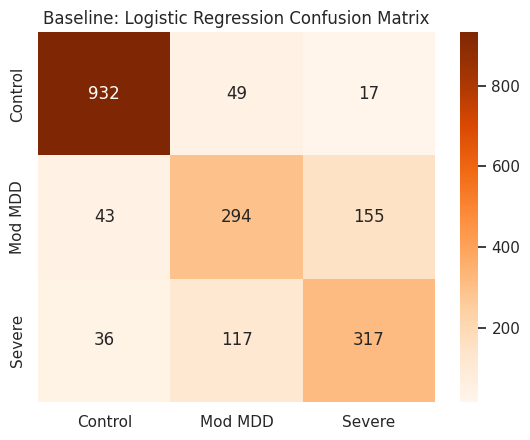

In [4]:
# Split the data globally for all models
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['selftext_cleaned'], df['target'], test_size=0.2, random_state=42, stratify=df['target']
)

# Vectorize Text
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_model.fit(X_train_tfidf, y_train)

# Predict & Metrics
y_pred_lr = lr_model.predict(X_test_tfidf)
print("Logistic Regression (TF-IDF) Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

# Visual Matrix
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=['Control', 'Mod MDD', 'Severe'], yticklabels=['Control', 'Mod MDD', 'Severe'])
plt.title('Baseline: Logistic Regression Confusion Matrix')
plt.show()

## 3. Advanced NLP Method: Embedding Generation (TwitterRoBERTa)
To capture deep semantic context surrounding medical keywords and depressive syntax, we encode the texts using HuggingFace's `cardiffnlp/twitter-roberta-base`.

> **Hardware Note:** Standard CPUs parse Transformers relatively slowly compared to NVIDIA CUDA. This specific cell dynamically routes to CUDA acceleration if you are using Google Colab's T4 GPU, rendering the entire dataset instantly. If you are running locally without an NVIDIA GPU, this cell detects it and gracefully scales down to fetch exactly 2000 items to fit perfectly within standard PC runtime margins.

In [5]:
import torch
from transformers import AutoTokenizer, AutoModel

# Setup Model Ecosystem with dynamic hardware routing
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Accelerating TwitterRoBERTa Embeddings via: {device}")

model_name = "cardiffnlp/twitter-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
bert_model = AutoModel.from_pretrained(model_name).to(device)
bert_model.eval() # Set purely to inference mode to save RAM

# If using Colab GPU, we can comfortably process all 10k rows.
# If running locally on CPU, we sample 2000 to save time.
n_samples = len(df) if torch.cuda.is_available() else 2000
df_bert_sample = df.sample(n=n_samples, random_state=42).reset_index(drop=True)
print(f"Subset processing for BERT generation: {df_bert_sample.shape[0]} documents")

Accelerating TwitterRoBERTa Embeddings via: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/565 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.decoder.bias      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Subset processing for BERT generation: 9800 documents


In [6]:
from tqdm.notebook import tqdm
import numpy as np

def get_batched_embeddings(texts, batch_size=32):
    all_embeddings = []
    # TQDM progress bar for Deep Learning inference
    for i in tqdm(range(0, len(texts), batch_size), desc="Generating Deep NLP Embeddings"):
        batch_texts = texts[i:i+batch_size].tolist()
        # Standardize input lengths to 512 max tokens and route to PyTorch hardware
        inputs = tokenizer(batch_texts, padding=True, truncation=True, max_length=512, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = bert_model(**inputs)
        # Extract [CLS] hidden state for the batch
        cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(cls_embeddings)
    return np.vstack(all_embeddings)

print("Starting Batched Inference... (Accelerated via PyTorch & TQDM)")
X_bert = get_batched_embeddings(df_bert_sample['selftext_cleaned'])
y_bert = df_bert_sample['target'].values


Starting Batched Inference... (Accelerated via PyTorch & TQDM)


Generating Deep NLP Embeddings:   0%|          | 0/307 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

## 4. Run Machine Learning Pipeline on TwitterRoBERTa Vectors
Now we pass the massive 768-dimension continuous feature vectors structurally to a Random Forest classifier.

TwitterRoBERTa + Random Forest Accuracy: 0.7418367346938776

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.95      0.89       998
           1       0.59      0.53      0.56       492
           2       0.65      0.52      0.58       470

    accuracy                           0.74      1960
   macro avg       0.69      0.67      0.67      1960
weighted avg       0.73      0.74      0.73      1960



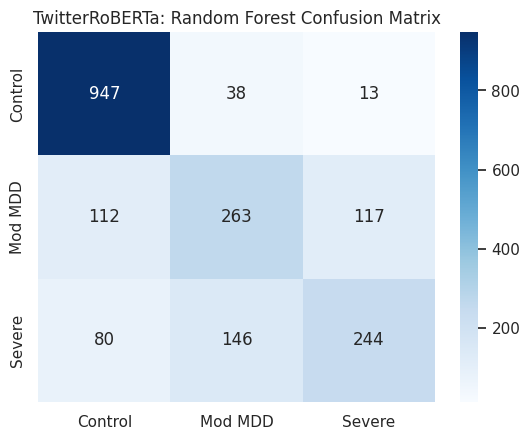

In [7]:
# Spilt the BERT Sample
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_bert, y_bert, test_size=0.2, random_state=42, stratify=y_bert
)

# We use Random Forest because continuous multi-dimensional embeddings work perfectly with tree depth models.
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_b, y_train_b)

y_pred_rf = rf_model.predict(X_test_b)
print("TwitterRoBERTa + Random Forest Accuracy:", accuracy_score(y_test_b, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test_b, y_pred_rf))

cm_rf = confusion_matrix(y_test_b, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=['Control', 'Mod MDD', 'Severe'], yticklabels=['Control', 'Mod MDD', 'Severe'])
plt.title('TwitterRoBERTa: Random Forest Confusion Matrix')
plt.show()

## 5. Explainable AI (SHAP)
Because Random forests and deep vectors act as black-boxes, we use SHAP (SHapley Additive exPlanations) to identify which words the classical model learned as strong indicators of severe ideation.
*(Note: Visualized on Logistic Regression to interpret vocabulary; Deep models take large GPU time to compute shapely values)*

SHAP Summary Plot for SEVERE IDEATION (Class 2):


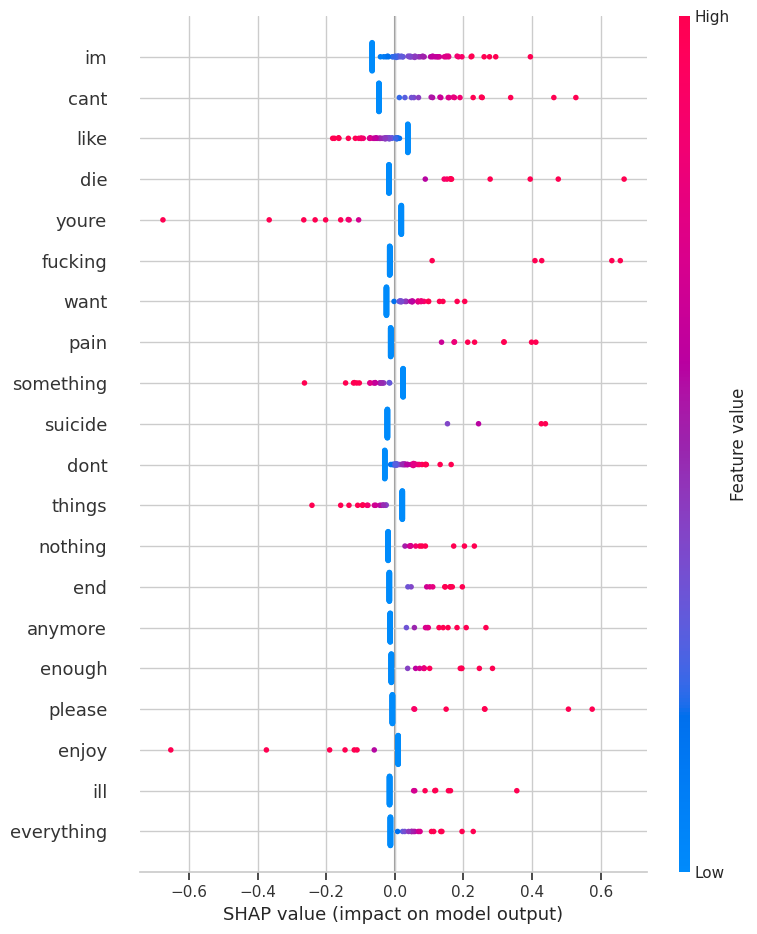

In [8]:
import shap
import warnings
warnings.filterwarnings('ignore')

# 1. SHAP for Logistic Regression (Track A) against test samples to explain token feature importance
# Taking a subset to prevent out-of-memory overhead during SHAP matrix generation
explainer_lr = shap.LinearExplainer(lr_model, X_train_tfidf, feature_names=tfidf.get_feature_names_out())
subset_idx = 100
shap_values_lr = explainer_lr.shap_values(X_test_tfidf[:subset_idx])

# Display SHAP summary visually for the 'Severe Ideation' class
# Note: For multi-class (0,1,2), shap_values_lr[:, :, 2] corresponds to 'Severe Ideation'
print("SHAP Summary Plot for SEVERE IDEATION (Class 2):")
shap.summary_plot(shap_values_lr[:, :, 2], X_test_tfidf[:subset_idx].toarray(), feature_names=tfidf.get_feature_names_out())

---
## 4. Exploratory Data Analysis & Language Pattern Detection
This section addresses the task-spec objective: *"Detect symptom and emotional language patterns"* and the suggested feature *"symptom keyword counts"*.

### 4.1 Symptom Keyword Counts
We define a curated list of DSM-5-aligned MDD symptom keywords and count their occurrences per class.

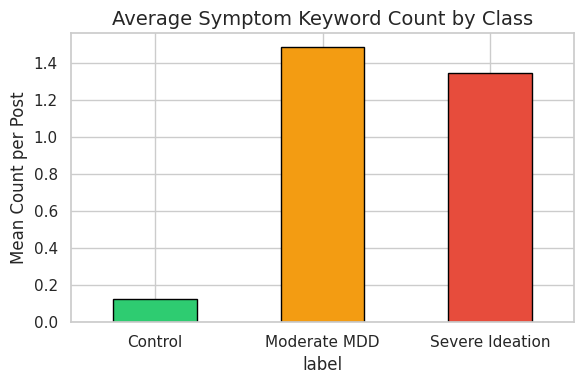

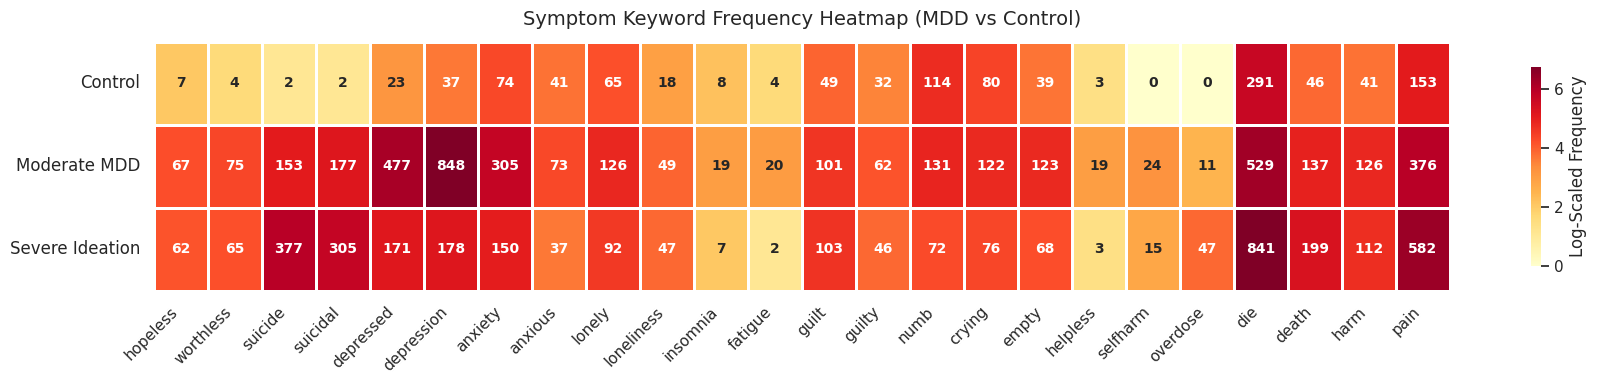

In [9]:
import numpy as np

# DSM-5-aligned MDD symptom keywords
SYMPTOM_KEYWORDS = [
    'hopeless', 'worthless', 'suicide', 'suicidal', 'depressed', 'depression',
    'anxiety', 'anxious', 'lonely', 'loneliness', 'insomnia', 'fatigue',
    'guilt', 'guilty', 'numb', 'crying', 'empty', 'helpless',
    'selfharm', 'overdose', 'die', 'death', 'harm', 'pain'
]

# Count total symptom keyword occurrences per post
def count_symptoms(text, keywords=SYMPTOM_KEYWORDS):
    if not isinstance(text, str):
        return 0
    tokens = text.lower().split()
    return sum(1 for t in tokens if t in keywords)

df['symptom_count'] = df['selftext_cleaned'].apply(count_symptoms)

# ── Figure 1: Average symptom count per class ──
fig, ax = plt.subplots(figsize=(6, 4))
class_means = df.groupby('label')['symptom_count'].mean()
class_means.plot(kind='bar', ax=ax, color=['#2ecc71', '#f39c12', '#e74c3c'], edgecolor='black')
ax.set_title('Average Symptom Keyword Count by Class', fontsize=14)
ax.set_ylabel('Mean Count per Post')
ax.set_xticklabels(['Control', 'Moderate MDD', 'Severe Ideation'], rotation=0)
plt.tight_layout()
plt.show()

# ── Figure 2: Keyword frequency heatmap (full-width, log-normalized) ──
keyword_freq = pd.DataFrame({
    kw: [df[df['label'] == 'Control']['selftext_cleaned'].str.count(kw).sum(),
         df[df['label'] == 'Moderate MDD']['selftext_cleaned'].str.count(kw).sum(),
         df[df['label'] == 'Severe Ideation']['selftext_cleaned'].str.count(kw).sum()]
    for kw in SYMPTOM_KEYWORDS
}, index=['Control', 'Moderate MDD', 'Severe Ideation'])

# Log1p normalization for better color contrast
keyword_freq_log = np.log1p(keyword_freq)

fig, ax = plt.subplots(figsize=(18, 4))
sns.heatmap(
    keyword_freq_log,
    annot=keyword_freq.values,  # Show raw counts as annotations
    fmt='g',
    cmap='YlOrRd',
    linewidths=0.8,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Log-Scaled Frequency', 'shrink': 0.8},
    annot_kws={'size': 10, 'weight': 'bold'}
)
ax.set_title('Symptom Keyword Frequency Heatmap (MDD vs Control)', fontsize=14, pad=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)
plt.tight_layout()
plt.show()

### 4.2 Word Clouds: Severity Tiers
Visual comparison of the dominant vocabulary in each class.

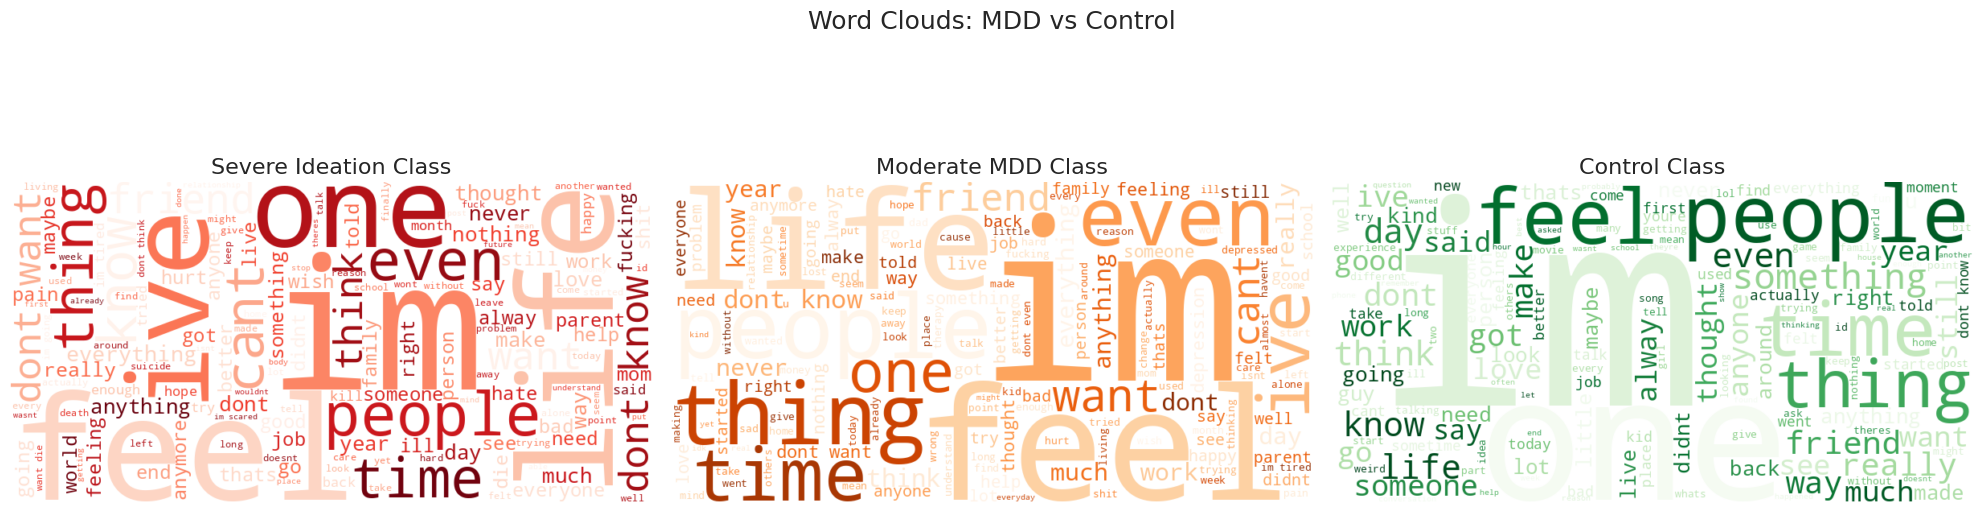

In [10]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, (label, color) in enumerate([('Severe Ideation', 'Reds'), ('Moderate MDD', 'Oranges'), ('Control', 'Greens')]):
    text = ' '.join(df[df['label'] == label]['selftext_cleaned'].dropna())
    wc = WordCloud(width=800, height=400, background_color='white',
                   colormap=color, max_words=150).generate(text)
    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].set_title(f'{label} Class', fontsize=16)
    axes[idx].axis('off')

plt.suptitle('Word Clouds: MDD vs Control', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

### 4.3 Sentiment Score Distribution
We compare the VADER compound sentiment score distributions across severity classes.

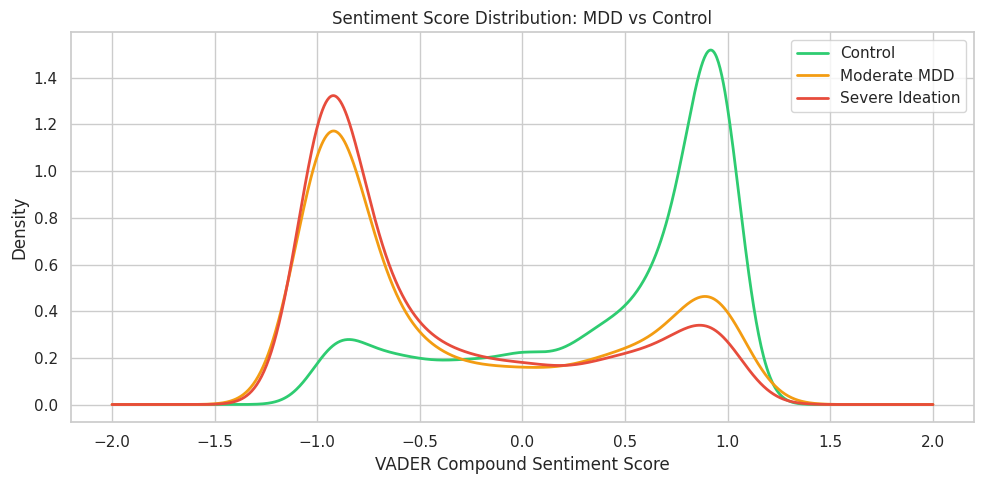

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))

for label, color in [('Control', '#2ecc71'), ('Moderate MDD', '#f39c12'), ('Severe Ideation', '#e74c3c')]:
    subset = df[df['label'] == label]['sentiment_score']
    subset.plot(kind='kde', ax=ax, label=label, color=color, linewidth=2)

ax.set_title('Sentiment Score Distribution: MDD vs Control')
ax.set_xlabel('VADER Compound Sentiment Score')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

### 4.4 Post Length Distribution
Research suggests depressive posts tend to be longer due to rumination.

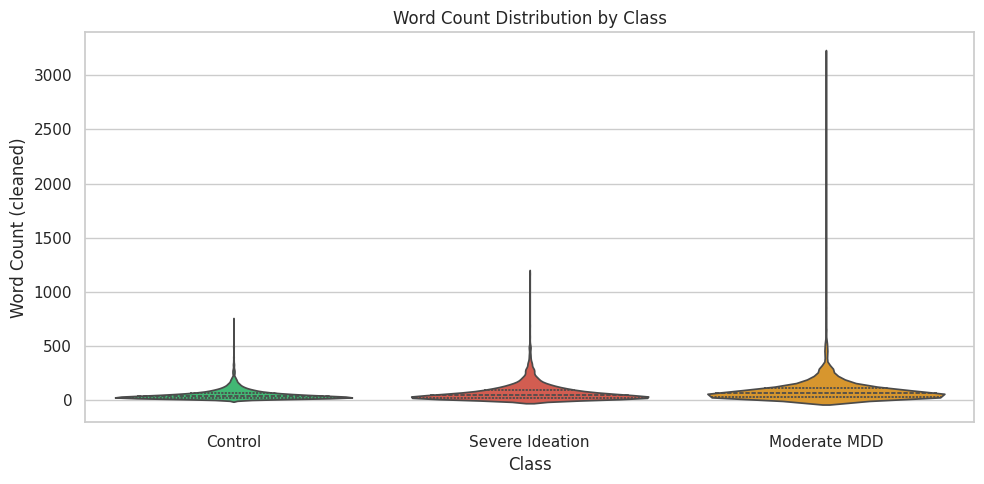

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.violinplot(x='label', y='word_count', data=df,
               palette={'Control': '#2ecc71', 'Moderate MDD': '#f39c12', 'Severe Ideation': '#e74c3c'},
               inner='quartile', ax=ax)
ax.set_title('Word Count Distribution by Class')
ax.set_xlabel('Class')
ax.set_ylabel('Word Count (cleaned)')
plt.tight_layout()
plt.show()

### 4.5 Top Bigrams: Severity Tiers
Bigrams capture multi-word phrases like *"feel like"*, *"can't sleep"*, etc.

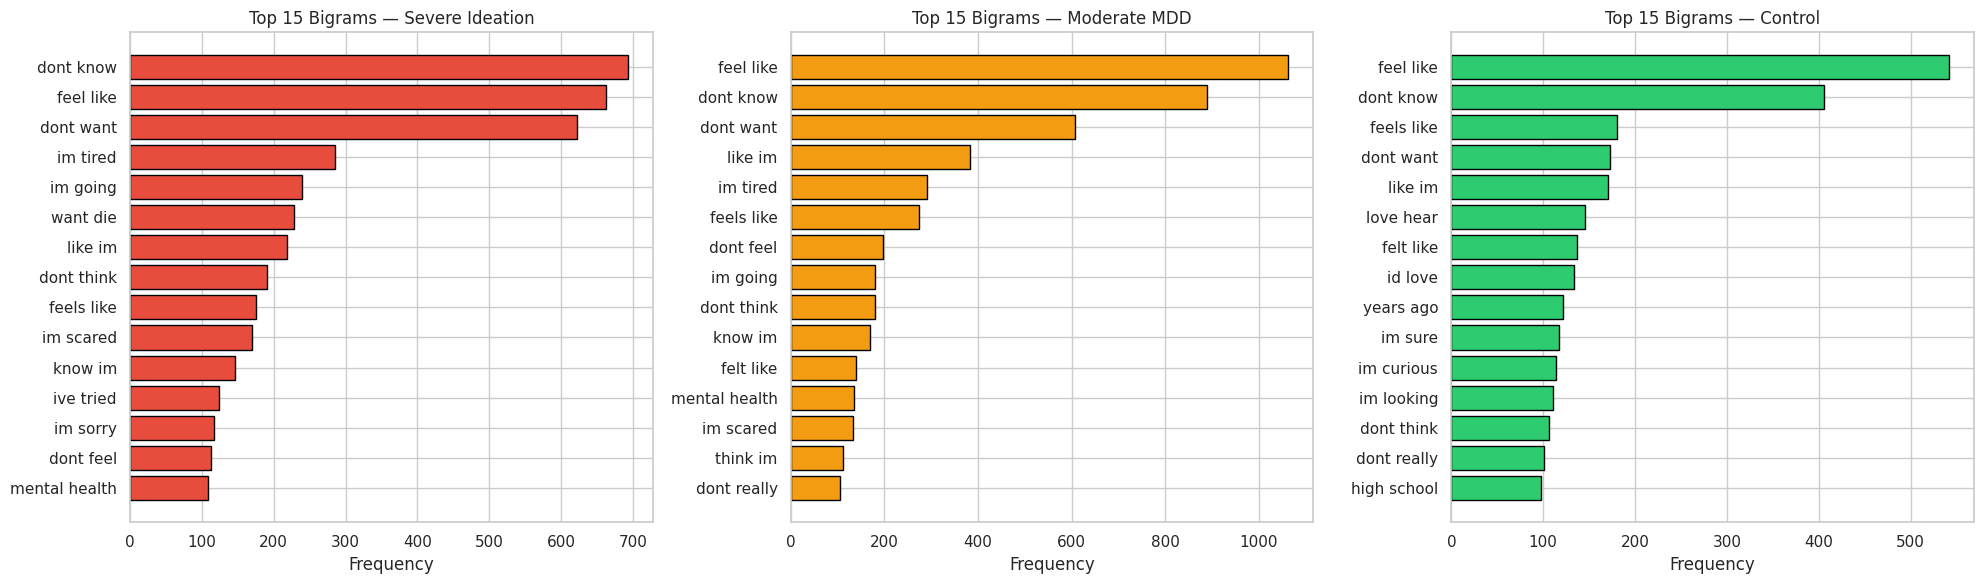

In [13]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngrams(corpus, n=2, top_k=15):
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english', max_features=10000)
    bag = vec.fit_transform(corpus)
    sum_words = bag.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:top_k]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, (label, color) in enumerate([('Severe Ideation', '#e74c3c'), ('Moderate MDD', '#f39c12'), ('Control', '#2ecc71')]):
    corpus = df[df['label'] == label]['selftext_cleaned'].dropna()
    top = get_top_ngrams(corpus, n=2, top_k=15)
    ngrams, counts = zip(*top)
    axes[idx].barh(range(len(ngrams)), counts, color=color, edgecolor='black')
    axes[idx].set_yticks(range(len(ngrams)))
    axes[idx].set_yticklabels(ngrams)
    axes[idx].invert_yaxis()
    axes[idx].set_title(f'Top 15 Bigrams — {label}')
    axes[idx].set_xlabel('Frequency')

plt.tight_layout()
plt.show()

### 4.6 ROC Validation Dropped
Since we transitioned to multi-class (3 classes), plotting simple binary ROC curves is no longer applicable. Explainability (SHAP) is prioritized instead.